<a href="https://colab.research.google.com/github/erxuanqi/mental-health-app-ux-analysis/blob/main/notebooks/03_transformer_and_bert_modelling_level4_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Check GPU availability
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


# Level 4–5: Transformer-assisted UX Review Analysis and BERT-based Rating Classification

This notebook extends the earlier exploratory, rule-based, and topic modelling analyses of the MHARD mental health app review dataset.

## Project Context

The purpose of this analysis is to examine how transformer-based NLP methods can support large-scale analysis of user experience (UX) feedback in digital mental health applications.

**Level 4** uses pre-trained transformer models for:
- sentiment analysis;
- rating–sentiment consistency analysis;
- disagreement analysis;
- zero-shot UX pain point classification.

These results are used to complement the TF-IDF analysis, rule-based UX pain point classification, and NMF topic modelling conducted in Levels 1–3.

**Level 5** conducts a small supervised learning experiment by fine-tuning DistilBERT to classify **low-rating versus high-rating reviews**. This is framed as a rating-derived user satisfaction classification task rather than a clinical prediction task.

## Ethical Boundary

This project analyses app reviews as product and UX feedback. It does **not** attempt to:

- diagnose mental health conditions;
- predict depression or other psychiatric disorders;
- detect suicide or self-harm risk;
- infer an individual user's mental health status;
- provide clinical risk assessment.

The transformer models are used only to analyse review language, UX feedback, and rating-derived user satisfaction.

## Research Focus

The central question is not whether transformer models outperform every simpler method, but whether they provide useful complementary evidence for understanding UX pain points and user satisfaction in digital mental health services.

## 2. Setup and Library Installation

The following libraries are used for transformer-based sentiment analysis, zero-shot classification, and DistilBERT fine-tuning.

In [ ]:
!pip -q install transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00


## 3. Import Libraries and Create Output Folders

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from datasets import Dataset

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Output folders
FIGURE_DIR = "/content/outputs/figures"
TABLE_DIR = "/content/outputs/tables"

os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

print("Libraries imported successfully.")
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")
print("Figure folder:", FIGURE_DIR)
print("Table folder:", TABLE_DIR)

Libraries imported successfully.
Device: GPU
Figure folder: /content/outputs/figures
Table folder: /content/outputs/tables


## 4. Load and Clean MHARD Dataset

The MHARD dataset is loaded directly from its official public repository. The cleaning and rating-group definitions follow the same logic used in the earlier levels of this project to maintain consistency across analyses.

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/Sensify-Lab/MHARD/main/MHARD_dataset.csv"

df_raw = pd.read_csv(DATA_URL)

print("Raw dataset shape:", df_raw.shape)
print("\nColumns:")
print(df_raw.columns.tolist())

df_raw.head()

Raw dataset shape: (200972, 16)

Columns:
['UID', 'app_name', 'rating', 'date', 'review', 'review_cleaned', 'likes', 'response_date', 'response', 'pred_gpt3.5instruct', 'pred_gpt3.5turbo', 'pred_gpt4', 'pred_gemini1.5flash', 'pred_gemini1.5pro', 'pred_llama3.1_8b', 'pred_llama3.3_70b']


,UID,app_name,rating,date,review,review_cleaned,likes,response_date,response,pred_gpt3.5instruct,pred_gpt3.5turbo,pred_gpt4,pred_gemini1.5flash,pred_gemini1.5pro,pred_llama3.1_8b,pred_llama3.3_70b
0,1,chiku,5,"August 17, 2020",I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,30,"August 23, 2020",We have fixed the issue in our latest update (...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
1,2,chiku,4,"December 22, 2020","I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,18,"December 22, 2020",Thank you so much for taking out time to write...,4.0,4.0,4.0,4.0,4.0,4.0,4.0
2,3,chiku,5,"March 02, 2022","I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,62,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
3,4,chiku,4,"April 27, 2023",This app is really great! Its has many feature...,app really great many feature thing apps pay p...,56,NaN,NaN,4.0,4.0,4.0,4.0,4.0,4.0,4.0
4,5,chiku,4,"April 10, 2023",This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,59,"April 13, 2023",We are really sorry for the inconvenience. We ...,2.0,2.0,2.0,2.0,3.0,3.0,2.0


In [ ]:
# Display all column names with index numbers
for i, col in enumerate(df_raw.columns):
    print(i, col)

0 UID
1 app_name
2 rating
3 date
4 review
5 review_cleaned
6 likes
7 response_date
8 response
9 pred_gpt3.5instruct
10 pred_gpt3.5turbo
11 pred_gpt4
12 pred_gemini1.5flash
13 pred_gemini1.5pro
14 pred_llama3.1_8b
15 pred_llama3.3_70b


In [ ]:
# Check missing values in each column
missing_summary = df_raw.isna().sum().sort_values(ascending=False)

print("Missing values by column:")
print(missing_summary)

Missing values by column:
response_date          148609
response               148609
pred_llama3.1_8b        10429
pred_gemini1.5flash      2403
pred_llama3.3_70b         885
pred_gpt4                 501
pred_gpt3.5instruct       305
review_cleaned            240
pred_gpt3.5turbo          191
pred_gemini1.5pro          54
review                     21
likes                       0
UID                         0
app_name                    0
rating                      0
date                        0
dtype: int64


In [ ]:
# Save a basic raw data inspection summary
raw_data_summary = pd.DataFrame({
    "item": ["raw_rows", "raw_columns"],
    "value": [df_raw.shape[0], df_raw.shape[1]]
})

raw_data_summary.to_csv(f"{TABLE_DIR}/level4_5_raw_data_summary.csv", index=False)

raw_data_summary

,item,value
0,raw_rows,200972
1,raw_columns,16


## 5. Clean Dataset and Define Rating Groups

The dataset is cleaned using the same logic as the previous notebooks. Reviews with missing or empty cleaned text are removed, and rating groups are defined as low, neutral, and high based on star ratings.

In [11]:
# Data cleaning and feature engineering
# This follows the same cleaning logic used in the Level 1–2 notebook.

# Make a copy of the original dataset
df_clean = df_raw.copy()

# Keep the main columns needed for this project
main_columns = [
    "UID",
    "app_name",
    "rating",
    "date",
    "review",
    "review_cleaned",
    "likes",
    "response_date",
    "response"
]

df_clean = df_clean[main_columns].copy()

# Remove rows with missing review text or missing rating
df_clean = df_clean.dropna(subset=["review", "rating"]).copy()

# Convert rating to numeric
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.dropna(subset=["rating"]).copy()
df_clean["rating"] = df_clean["rating"].astype(int)

# Remove duplicate reviews within the same app
df_clean = df_clean.drop_duplicates(subset=["app_name", "review"]).copy()

# Convert text columns to string
df_clean["review"] = df_clean["review"].astype(str)
df_clean["review_cleaned"] = df_clean["review_cleaned"].astype(str)

# Create rating groups
def create_rating_group(rating):
    if rating <= 2:
        return "Low rating"
    elif rating == 3:
        return "Neutral rating"
    else:
        return "High rating"

df_clean["rating_group"] = df_clean["rating"].apply(create_rating_group)

# Create text length features
df_clean["review_length"] = df_clean["review"].str.len()
df_clean["word_count"] = df_clean["review"].str.split().str.len()

# Create developer response indicator
df_clean["has_response"] = df_clean["response"].notnull()

# Use existing cleaned review text as the main clean text column
df_clean["clean_text"] = df_clean["review_cleaned"]

# Remove rows with empty clean text
df_clean = df_clean[df_clean["clean_text"].str.strip() != ""].copy()

# Reset index
df_clean = df_clean.reset_index(drop=True)

# For consistency with later Level 4–5 code, use df as the main working dataframe
df = df_clean.copy()

print("Data cleaning completed.")
print("Original number of rows:", df_raw.shape[0])
print("Cleaned number of rows:", df_clean.shape[0])
print("Number of columns after cleaning:", df_clean.shape[1])

print("\nCleaned dataset shape:")
print(df_clean.shape)

print("\nRating group distribution:")
print(df_clean["rating_group"].value_counts())

print("\nPreview of selected columns:")
df_clean[["app_name", "rating", "rating_group", "review", "clean_text", "review_length", "word_count", "has_response"]].head()

Data cleaning completed.
Original number of rows: 200972
Cleaned number of rows: 194774
Number of columns after cleaning: 14

Cleaned dataset shape:
(194774, 14)

Rating group distribution:
rating_group
High rating       141642
Low rating         42322
Neutral rating     10810
Name: count, dtype: int64

Preview of selected columns:


,app_name,rating,rating_group,review,clean_text,review_length,word_count,has_response
0,chiku,5,High rating,I'm digging it. journaling everything I do dur...,im digging journaling everything day complaint...,386,76,True
1,chiku,4,High rating,"I really like this app, however, the awesome s...",really like app however awesome smiley graphic...,500,94,True
2,chiku,5,High rating,"I love this. It's so calming, and relaxing, an...",love calming relaxing definitely one favorite ...,494,93,False
3,chiku,4,High rating,This app is really great! Its has many feature...,app really great many feature thing apps pay p...,493,99,False
4,chiku,4,High rating,This app used to be amazing but now whenever I...,app used amazing whenever try make story start...,309,59,True


In [12]:
# Save cleaned data summary
cleaned_data_summary = pd.DataFrame({
    "item": [
        "cleaned_rows",
        "cleaned_columns",
        "high_rating_reviews",
        "low_rating_reviews",
        "neutral_rating_reviews"
    ],
    "value": [
        df_clean.shape[0],
        df_clean.shape[1],
        (df_clean["rating_group"] == "High rating").sum(),
        (df_clean["rating_group"] == "Low rating").sum(),
        (df_clean["rating_group"] == "Neutral rating").sum()
    ]
})

cleaned_data_summary.to_csv(f"{TABLE_DIR}/level4_5_cleaned_data_summary.csv", index=False)

cleaned_data_summary

,item,value
0,cleaned_rows,194774
1,cleaned_columns,14
2,high_rating_reviews,141642
3,low_rating_reviews,42322
4,neutral_rating_reviews,10810


## 6. Prepare Stratified Samples

To keep the transformer-based analyses computationally feasible in Colab, this notebook uses stratified samples rather than the full dataset.

Three samples are prepared:

1. A stratified sample for Level 4 sentiment analysis.
2. A smaller low-rating sample for Level 4 zero-shot UX pain point classification.
3. A balanced low-rating versus high-rating sample for Level 5 DistilBERT fine-tuning.

This sampling strategy allows the notebook to demonstrate transformer-assisted UX analysis while remaining practical for a beginner-friendly Colab workflow.

In [13]:
# Split by rating group
low_df = df_clean[df_clean["rating_group"] == "Low rating"].copy()
neutral_df = df_clean[df_clean["rating_group"] == "Neutral rating"].copy()
high_df = df_clean[df_clean["rating_group"] == "High rating"].copy()

# Level 4A: stratified sentiment analysis sample
sentiment_sample = pd.concat([
    low_df.sample(n=1000, random_state=SEED),
    neutral_df.sample(n=500, random_state=SEED),
    high_df.sample(n=1000, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

# Level 4C: zero-shot pain point classification sample
zero_shot_sample = low_df.sample(n=300, random_state=SEED).reset_index(drop=True)

# Level 5: balanced binary classification sample
level5_sample = pd.concat([
    low_df.sample(n=2000, random_state=SEED),
    high_df.sample(n=2000, random_state=SEED)
]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Sentiment sample shape:", sentiment_sample.shape)
print(sentiment_sample["rating_group"].value_counts())

print("\nZero-shot sample shape:", zero_shot_sample.shape)
print(zero_shot_sample["rating_group"].value_counts())

print("\nLevel 5 sample shape:", level5_sample.shape)
print(level5_sample["rating_group"].value_counts())

Sentiment sample shape: (2500, 14)
rating_group
High rating       1000
Low rating        1000
Neutral rating     500
Name: count, dtype: int64

Zero-shot sample shape: (300, 14)
rating_group
Low rating    300
Name: count, dtype: int64

Level 5 sample shape: (4000, 14)
rating_group
Low rating     2000
High rating    2000
Name: count, dtype: int64


# Part A: Level 4 - Transformer-assisted UX Review Analysis

## 7. Transformer Sentiment Analysis

This section uses a pre-trained transformer sentiment analysis model to examine whether review text sentiment is consistent with the user-provided star rating.

The analysis focuses on product and user experience feedback rather than clinical interpretation. The sentiment model is used to classify review language as positive or negative, and the results are compared with rating groups.

In [14]:
# Load transformer sentiment analysis pipeline
sentiment_model_name = "distilbert-base-uncased-finetuned-sst-2-english"

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=sentiment_model_name,
    device=0 if torch.cuda.is_available() else -1
)

print("Sentiment pipeline loaded successfully.")
print("Model:", sentiment_model_name)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Sentiment pipeline loaded successfully.
Model: distilbert-base-uncased-finetuned-sst-2-english
Device: GPU


In [15]:
# Test the sentiment pipeline on a few reviews before running the full sample
test_reviews = sentiment_sample["clean_text"].head(5).tolist()

test_results = sentiment_pipeline(
    test_reviews,
    truncation=True,
    max_length=512
)

for review, result in zip(test_reviews, test_results):
    print("Review:", review[:200])
    print("Prediction:", result)
    print("-" * 80)

Review: would love pay app certainly much certainly something glitchy start game app restarts serenity scene free play doesnt sound among bug work positive attractive app would like pay cost entire app per mo
Prediction: {'label': 'NEGATIVE', 'score': 0.9588178396224976}
--------------------------------------------------------------------------------
Review: used love app feel though gotten worse old format much nicer navigate barely free option anymore upset say app longer help
Prediction: {'label': 'NEGATIVE', 'score': 0.9983258843421936}
--------------------------------------------------------------------------------
Review: downloaded today listen minute session even though wasnt sitting instructed spending mind focused breathing technique say think really everyone need continue update
Prediction: {'label': 'NEGATIVE', 'score': 0.6176711320877075}
--------------------------------------------------------------------------------
Review: great application ton audio short music awesome

In [16]:
# Run sentiment analysis on the stratified sample

texts = sentiment_sample["clean_text"].astype(str).tolist()

sentiment_results = sentiment_pipeline(
    texts,
    truncation=True,
    max_length=512,
    batch_size=32
)

sentiment_sample["predicted_sentiment"] = [result["label"] for result in sentiment_results]
sentiment_sample["sentiment_score"] = [result["score"] for result in sentiment_results]

print("Sentiment analysis completed.")
print("Sample shape:", sentiment_sample.shape)

sentiment_sample[[
    "app_name",
    "rating",
    "rating_group",
    "predicted_sentiment",
    "sentiment_score",
    "clean_text"
]].head()

Sentiment analysis completed.
Sample shape: (2500, 16)


,app_name,rating,rating_group,predicted_sentiment,sentiment_score,clean_text
0,happify,3,Neutral rating,NEGATIVE,0.958818,would love pay app certainly much certainly so...
1,headspace,3,Neutral rating,NEGATIVE,0.998326,used love app feel though gotten worse old for...
2,calm,3,Neutral rating,NEGATIVE,0.617672,downloaded today listen minute session even th...
3,calm,5,High rating,POSITIVE,0.999235,great application ton audio short music awesom...
4,calm,4,High rating,POSITIVE,0.962703,love calm app premium stink tho cause really w...


## 8. Sentiment Distribution by Rating Group

This section compares transformer-predicted sentiment labels with user-provided rating groups. The purpose is to examine whether star ratings and textual sentiment generally align, and where they diverge.

In [17]:
# Create sentiment summary table by rating group

sentiment_summary = pd.crosstab(
    sentiment_sample["rating_group"],
    sentiment_sample["predicted_sentiment"],
    margins=True
)

sentiment_percentage = pd.crosstab(
    sentiment_sample["rating_group"],
    sentiment_sample["predicted_sentiment"],
    normalize="index"
) * 100

print("Sentiment count table:")
display(sentiment_summary)

print("\nSentiment percentage table:")
display(sentiment_percentage.round(2))

# Save count summary
sentiment_summary.to_csv(f"{TABLE_DIR}/level4_sentiment_summary.csv")

print("Saved to:", f"{TABLE_DIR}/level4_sentiment_summary.csv")

Sentiment count table:


predicted_sentiment,NEGATIVE,POSITIVE,All
rating_group,,,
High rating,231,769,1000
Low rating,907,93,1000
Neutral rating,353,147,500
All,1491,1009,2500



Sentiment percentage table:


predicted_sentiment,NEGATIVE,POSITIVE
rating_group,,
High rating,23.1,76.9
Low rating,90.7,9.3
Neutral rating,70.6,29.4


Saved to: /content/outputs/tables/level4_sentiment_summary.csv


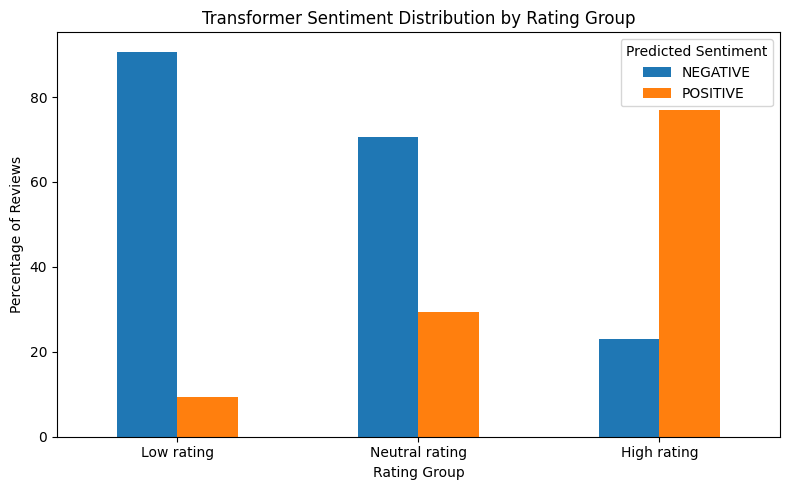

Figure saved to: /content/outputs/figures/level4_sentiment_by_rating_group.png


In [18]:
# Plot sentiment distribution by rating group

sentiment_plot_data = pd.crosstab(
    sentiment_sample["rating_group"],
    sentiment_sample["predicted_sentiment"],
    normalize="index"
) * 100

sentiment_plot_data = sentiment_plot_data.loc[
    ["Low rating", "Neutral rating", "High rating"]
]

ax = sentiment_plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Transformer Sentiment Distribution by Rating Group")
plt.xlabel("Rating Group")
plt.ylabel("Percentage of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Predicted Sentiment")
plt.tight_layout()

figure_path = f"{FIGURE_DIR}/level4_sentiment_by_rating_group.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)

## 9. Rating-Sentiment Disagreement Analysis

This section examines cases where user-provided ratings and transformer-predicted sentiment do not align.

Two disagreement patterns are especially important for UX analysis:

1. **Low rating but positive sentiment**: users may express appreciation for the app concept or content while giving a low rating because of pricing, subscription barriers, bugs, or access problems.
2. **High rating but negative sentiment**: users may report specific frustrations despite giving a high rating, or the model may misclassify mixed, sarcastic, or context-dependent reviews.

These disagreement cases are useful because they reveal that star ratings and review sentiment capture different aspects of user experience.

In [19]:
# Identify rating-sentiment disagreement cases

low_positive = sentiment_sample[
    (sentiment_sample["rating_group"] == "Low rating") &
    (sentiment_sample["predicted_sentiment"] == "POSITIVE")
].copy()

high_negative = sentiment_sample[
    (sentiment_sample["rating_group"] == "High rating") &
    (sentiment_sample["predicted_sentiment"] == "NEGATIVE")
].copy()

print("Low rating but predicted POSITIVE:", low_positive.shape[0])
print("High rating but predicted NEGATIVE:", high_negative.shape[0])

print("\nExamples: Low rating but predicted POSITIVE")
display(
    low_positive[[
        "app_name",
        "rating",
        "rating_group",
        "predicted_sentiment",
        "sentiment_score",
        "clean_text"
    ]].head(5)
)

print("\nExamples: High rating but predicted NEGATIVE")
display(
    high_negative[[
        "app_name",
        "rating",
        "rating_group",
        "predicted_sentiment",
        "sentiment_score",
        "clean_text"
    ]].head(5)
)

Low rating but predicted POSITIVE: 93
High rating but predicted NEGATIVE: 231

Examples: Low rating but predicted POSITIVE


,app_name,rating,rating_group,predicted_sentiment,sentiment_score,clean_text
24,voice,1,Low rating,POSITIVE,0.994888,im giving
54,minddiagnostics,2,Low rating,POSITIVE,0.999684,self diagnosing good
114,digitalwellbeing,1,Low rating,POSITIVE,0.927088,cant use setting
122,breeze,1,Low rating,POSITIVE,0.999864,worth time
130,digitalwellbeing,1,Low rating,POSITIVE,0.994224,app able update showing pending



Examples: High rating but predicted NEGATIVE


,app_name,rating,rating_group,predicted_sentiment,sentiment_score,clean_text
6,moodpress,5,High rating,NEGATIVE,0.612374,love illustration graphic uiux icon spacing ca...
33,intellect,5,High rating,NEGATIVE,0.998172,many hole straw
40,fabulous,4,High rating,NEGATIVE,0.994409,like reminds need sound like saying name letti...
42,headspace,5,High rating,NEGATIVE,0.987972,ive used time effective time expect get better
51,daylio,5,High rating,NEGATIVE,0.558653,honestly app good bought premium version im de...


In [20]:
# Create and save disagreement summary without exporting full review text

disagreement_summary = pd.DataFrame({
    "disagreement_type": [
        "Low rating but predicted POSITIVE",
        "High rating but predicted NEGATIVE"
    ],
    "count": [
        low_positive.shape[0],
        high_negative.shape[0]
    ],
    "percentage_within_relevant_rating_group": [
        low_positive.shape[0] / 1000 * 100,
        high_negative.shape[0] / 1000 * 100
    ],
    "ux_interpretation": [
        "Users may like the app concept or content but give low ratings because of pricing, subscriptions, bugs, or access barriers.",
        "Users may give high ratings while still describing frustrations, or the model may misclassify mixed, sarcastic, or context-dependent reviews."
    ]
})

disagreement_summary.to_csv(
    f"{TABLE_DIR}/level4_disagreement_summary.csv",
    index=False
)

disagreement_summary

,disagreement_type,count,percentage_within_relevant_rating_group,ux_interpretation
0,Low rating but predicted POSITIVE,93,9.3,Users may like the app concept or content but ...
1,High rating but predicted NEGATIVE,231,23.1,Users may give high ratings while still descri...


## 10. Interpretation of Transformer Sentiment Results

The transformer sentiment analysis shows a clear relationship between user-provided star ratings and review text sentiment.

In the stratified sample, most low-rating reviews were classified as negative, while most high-rating reviews were classified as positive. This suggests that transformer-predicted sentiment broadly aligns with rating-derived user satisfaction.

However, the results also show meaningful disagreement between ratings and predicted sentiment. Some low-rating reviews were predicted as positive, suggesting that users may appreciate the app concept, content, or design while still assigning a low rating because of pricing barriers, subscription restrictions, technical problems, or access issues. Conversely, some high-rating reviews were predicted as negative, suggesting mixed experiences, specific frustrations within otherwise positive reviews, or limitations of the sentiment model when handling short, cleaned, ambiguous, or context-dependent review text.

For UX and digital health analysis, these disagreement cases are important because they show that star ratings and sentiment predictions capture related but not identical dimensions of user experience.

## 11. Zero-shot UX Pain Point Classification

This section uses a pre-trained zero-shot classification model to assign low-rating reviews to UX pain point categories without training a project-specific classifier.

The purpose is not to replace the rule-based pain point classification from Level 2 or the NMF topic modelling from Level 3. Instead, zero-shot classification is used as an additional transformer-assisted method to examine whether similar UX issue categories emerge from review text.

The classification labels are designed around product, service, and UX problems rather than clinical or diagnostic categories.

In [21]:
# Candidate UX pain point labels for zero-shot classification

candidate_labels = [
    "pricing or subscription issue",
    "technical issue",
    "account or login issue",
    "usability or interface issue",
    "content quality or effectiveness issue",
    "customer support issue",
    "privacy or trust issue",
    "unclear issue"
]

print("Candidate labels:")
for label in candidate_labels:
    print("-", label)

Candidate labels:
- pricing or subscription issue
- technical issue
- account or login issue
- usability or interface issue
- content quality or effectiveness issue
- customer support issue
- privacy or trust issue
- unclear issue


In [22]:
# Load zero-shot classification pipeline
zero_shot_model_name = "facebook/bart-large-mnli"

zero_shot_pipeline = pipeline(
    "zero-shot-classification",
    model=zero_shot_model_name,
    device=0 if torch.cuda.is_available() else -1
)

print("Zero-shot pipeline loaded successfully.")
print("Model:", zero_shot_model_name)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Zero-shot pipeline loaded successfully.
Model: facebook/bart-large-mnli
Device: GPU


In [23]:
# Test zero-shot classification on a few low-rating reviews

test_zero_shot_reviews = zero_shot_sample["clean_text"].head(3).astype(str).tolist()

for i, review in enumerate(test_zero_shot_reviews):
    result = zero_shot_pipeline(
        review,
        candidate_labels=candidate_labels,
        multi_label=False
    )

    print(f"Review {i+1}:")
    print(review[:300])
    print("Top label:", result["labels"][0])
    print("Top score:", round(result["scores"][0], 4))
    print("All labels ranked:")
    for label, score in zip(result["labels"], result["scores"]):
        print(f"  {label}: {score:.4f}")
    print("-" * 80)

Review 1:
basically using space phone unable pick track continue getting error message telling go app manager problem continues slap unable open feature im pas start process
Top label: technical issue
Top score: 0.3553
All labels ranked:
  technical issue: 0.3553
  unclear issue: 0.2919
  usability or interface issue: 0.2902
  account or login issue: 0.0188
  customer support issue: 0.0159
  content quality or effectiveness issue: 0.0147
  privacy or trust issue: 0.0107
  pricing or subscription issue: 0.0024
--------------------------------------------------------------------------------
Review 2:
per year really im tired overpriced gps apps recommend due high annual cost
Top label: pricing or subscription issue
Top score: 0.8718
All labels ranked:
  pricing or subscription issue: 0.8718
  unclear issue: 0.0341
  usability or interface issue: 0.0248
  content quality or effectiveness issue: 0.0202
  account or login issue: 0.0146
  technical issue: 0.0144
  privacy or trust issue: 0.0

In [24]:
# Run zero-shot UX pain point classification on the low-rating sample

zero_shot_labels = []
zero_shot_scores = []

texts = zero_shot_sample["clean_text"].astype(str).tolist()

for i, text in enumerate(texts):
    result = zero_shot_pipeline(
        text,
        candidate_labels=candidate_labels,
        multi_label=False
    )

    zero_shot_labels.append(result["labels"][0])
    zero_shot_scores.append(result["scores"][0])

    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1} / {len(texts)} reviews")

zero_shot_sample["zero_shot_pain_point_label"] = zero_shot_labels
zero_shot_sample["zero_shot_score"] = zero_shot_scores

print("Zero-shot classification completed.")
print("Sample shape:", zero_shot_sample.shape)

zero_shot_sample[[
    "app_name",
    "rating",
    "rating_group",
    "zero_shot_pain_point_label",
    "zero_shot_score",
    "clean_text"
]].head()

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 50 / 300 reviews
Processed 100 / 300 reviews
Processed 150 / 300 reviews
Processed 200 / 300 reviews
Processed 250 / 300 reviews
Processed 300 / 300 reviews
Zero-shot classification completed.
Sample shape: (300, 16)


,app_name,rating,rating_group,zero_shot_pain_point_label,zero_shot_score,clean_text
0,happify,1,Low rating,technical issue,0.355263,basically using space phone unable pick track ...
1,remente,1,Low rating,pricing or subscription issue,0.871822,per year really im tired overpriced gps apps r...
2,welltory,1,Low rating,unclear issue,0.534475,fraud health app dont believe result show well...
3,anxietyrelief,1,Low rating,content quality or effectiveness issue,0.297039,trouble app used work good last update paid re...
4,breeze,1,Low rating,unclear issue,0.335891,tried second saw u pay thanks mental health im...


## 12. Zero-shot Pain Point Distribution

The zero-shot model assigns each sampled low-rating review to the most likely UX pain point category. The distribution is used as transformer-assisted evidence for identifying common pain points in digital mental health app reviews.

In [25]:
# Summarise zero-shot pain point labels

zero_shot_summary = (
    zero_shot_sample["zero_shot_pain_point_label"]
    .value_counts()
    .reset_index()
)

zero_shot_summary.columns = ["zero_shot_pain_point_label", "review_count"]
zero_shot_summary["percentage"] = (
    zero_shot_summary["review_count"] / zero_shot_summary["review_count"].sum() * 100
).round(2)

zero_shot_summary.to_csv(
    f"{TABLE_DIR}/level4_zero_shot_pain_point_summary.csv",
    index=False
)

zero_shot_summary

,zero_shot_pain_point_label,review_count,percentage
0,unclear issue,141,47.00
1,usability or interface issue,61,20.33
2,pricing or subscription issue,45,15.00
3,content quality or effectiveness issue,18,6.00
4,account or login issue,17,5.67
5,privacy or trust issue,11,3.67
6,technical issue,7,2.33


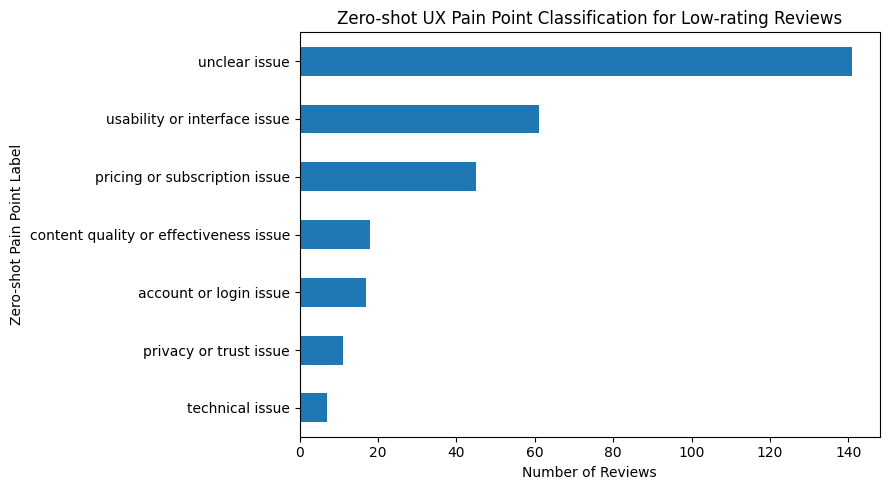

Figure saved to: /content/outputs/figures/level4_zero_shot_pain_point_distribution.png


In [26]:
# Plot zero-shot UX pain point distribution

plot_data = zero_shot_summary.sort_values("review_count", ascending=True)

ax = plot_data.plot(
    x="zero_shot_pain_point_label",
    y="review_count",
    kind="barh",
    figsize=(9, 5),
    legend=False
)

plt.title("Zero-shot UX Pain Point Classification for Low-rating Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Zero-shot Pain Point Label")
plt.tight_layout()

figure_path = f"{FIGURE_DIR}/level4_zero_shot_pain_point_distribution.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure saved to:", figure_path)

In [27]:
# Save anonymised zero-shot classification results without full review text

zero_shot_results_export = zero_shot_sample[[
    "app_name",
    "rating",
    "rating_group",
    "zero_shot_pain_point_label",
    "zero_shot_score"
]].copy()

zero_shot_results_export.to_csv(
    f"{TABLE_DIR}/level4_zero_shot_results_anonymised.csv",
    index=False
)

print("Saved anonymised zero-shot results to:")
print(f"{TABLE_DIR}/level4_zero_shot_results_anonymised.csv")

zero_shot_results_export.head()

Saved anonymised zero-shot results to:
/content/outputs/tables/level4_zero_shot_results_anonymised.csv


,app_name,rating,rating_group,zero_shot_pain_point_label,zero_shot_score
0,happify,1,Low rating,technical issue,0.355263
1,remente,1,Low rating,pricing or subscription issue,0.871822
2,welltory,1,Low rating,unclear issue,0.534475
3,anxietyrelief,1,Low rating,content quality or effectiveness issue,0.297039
4,breeze,1,Low rating,unclear issue,0.335891


## 13. Interpretation of Zero-shot UX Pain Point Classification

The zero-shot classification results suggest that transformer-assisted labelling can help identify broad UX pain point patterns in low-rating mental health app reviews.

In this sample, the most frequent category was **unclear issue**, followed by categories such as **usability or interface issue** and **pricing or subscription issue**. This indicates that while the zero-shot model can identify some interpretable UX categories, many cleaned reviews remain difficult to classify confidently.

The high proportion of unclear classifications is methodologically important. Many app reviews are short, informal, grammatically incomplete, or contain mixed complaints. As a result, zero-shot classification should not be treated as a definitive replacement for rule-based classification or topic modelling.

Instead, zero-shot classification is best understood as a complementary method. It provides a transformer-assisted perspective that can be compared with the Level 2 rule-based pain point categories and the Level 3 NMF topic modelling results.

## 14. Level 4 Method Comparison

This section compares the role of different analytical methods used across the project. The aim is to clarify why each method was used and how it contributes to UX, HCI, and digital health insight generation.

In [28]:
# Create method comparison table

method_comparison = pd.DataFrame({
    "method": [
        "TF-IDF keyword analysis",
        "Rule-based pain point classification",
        "NMF topic modelling",
        "Transformer sentiment analysis",
        "Zero-shot UX pain point classification"
    ],
    "purpose": [
        "Identify frequently weighted terms in high-rating and low-rating reviews.",
        "Assign reviews to predefined UX pain point categories using transparent rules.",
        "Discover interpretable latent topics within low-rating reviews.",
        "Compare transformer-predicted review sentiment with user-provided rating groups.",
        "Assign low-rating reviews to UX pain point labels using a pre-trained transformer model."
    ],
    "strength": [
        "Simple, fast, interpretable, and useful for identifying salient vocabulary.",
        "Highly transparent and easy to connect with UX categories and design implications.",
        "Reveals broader themes beyond individual keywords and complements rule-based categories.",
        "Captures contextual sentiment beyond keyword frequency and enables rating-sentiment disagreement analysis.",
        "Can classify reviews into semantic UX categories without project-specific labelled training data."
    ],
    "limitation": [
        "Does not capture deeper context, negation, sarcasm, or multi-word meanings well.",
        "Depends on manually defined keyword rules and may miss unexpected or implicit issues.",
        "Requires human interpretation of topics and can be sensitive to preprocessing and number of topics.",
        "Sentiment labels may oversimplify mixed experiences and can be unreliable for short or ambiguous reviews.",
        "Can produce high unclear rates and may be unstable when candidate labels do not fully match review language."
    ],
    "role_in_project": [
        "Provides baseline evidence for common language patterns in app reviews.",
        "Translates review text into actionable UX pain point categories.",
        "Validates and enriches the Level 2 pain point structure through unsupervised topic discovery.",
        "Tests whether textual sentiment broadly aligns with rating-derived user satisfaction.",
        "Provides a transformer-assisted comparison point for UX pain point labelling."
    ]
})

method_comparison.to_csv(
    f"{TABLE_DIR}/level4_method_comparison.csv",
    index=False
)

method_comparison

,method,purpose,strength,limitation,role_in_project
0,TF-IDF keyword analysis,Identify frequently weighted terms in high-rat...,"Simple, fast, interpretable, and useful for id...","Does not capture deeper context, negation, sar...",Provides baseline evidence for common language...
1,Rule-based pain point classification,Assign reviews to predefined UX pain point cat...,Highly transparent and easy to connect with UX...,Depends on manually defined keyword rules and ...,Translates review text into actionable UX pain...
2,NMF topic modelling,Discover interpretable latent topics within lo...,Reveals broader themes beyond individual keywo...,Requires human interpretation of topics and ca...,Validates and enriches the Level 2 pain point ...
3,Transformer sentiment analysis,Compare transformer-predicted review sentiment...,Captures contextual sentiment beyond keyword f...,Sentiment labels may oversimplify mixed experi...,Tests whether textual sentiment broadly aligns...
4,Zero-shot UX pain point classification,Assign low-rating reviews to UX pain point lab...,Can classify reviews into semantic UX categori...,Can produce high unclear rates and may be unst...,Provides a transformer-assisted comparison poi...


## 15. Level 4 Summary

Level 4 demonstrates how pre-trained transformer models can support large-scale UX review analysis in digital mental health apps.

The sentiment analysis results show that transformer-predicted sentiment broadly aligns with user-provided star ratings: low-rating reviews are mostly classified as negative, while high-rating reviews are mostly classified as positive. However, disagreement cases reveal important UX complexity. Some users express positive language while still giving low ratings, often suggesting dissatisfaction with pricing, subscription barriers, technical issues, or access limitations. Other users give high ratings while still describing frustrations, which may reflect mixed experiences or model limitations.

The zero-shot classification results show that transformer-assisted labelling can identify broad UX pain point categories, but the high proportion of unclear classifications also highlights the limitations of applying general-purpose models to short, informal, and cleaned app review text.

Overall, Level 4 supports the project argument that transformer methods are useful complements to TF-IDF, rule-based classification, and NMF topic modelling, but they should be interpreted carefully rather than treated as automatic ground truth.

# Part B: Level 5 - BERT-based Rating Classification

## 16. Prepare Binary Rating Classification Dataset

Level 5 conducts a small supervised learning experiment using DistilBERT to classify low-rating versus high-rating reviews.

This is a rating-derived user satisfaction classification task. The model predicts whether a review is associated with low or high user satisfaction based on review text.

This task does **not** predict mental health conditions, clinical risk, or individual psychological status.

In [29]:
# Prepare binary labels for Level 5

level5_df = level5_sample.copy()

# Keep only Low rating and High rating
level5_df = level5_df[
    level5_df["rating_group"].isin(["Low rating", "High rating"])
].copy()

# Create binary label
# 0 = Low rating, 1 = High rating
level5_df["label"] = level5_df["rating_group"].map({
    "Low rating": 0,
    "High rating": 1
})

# Keep only necessary columns for modelling
level5_df = level5_df[[
    "app_name",
    "rating",
    "rating_group",
    "clean_text",
    "label"
]].copy()

print("Level 5 dataset shape:", level5_df.shape)
print("\nLabel distribution:")
print(level5_df["label"].value_counts())
print("\nRating group distribution:")
print(level5_df["rating_group"].value_counts())

level5_df.head()

Level 5 dataset shape: (4000, 5)

Label distribution:
label
0    2000
1    2000
Name: count, dtype: int64

Rating group distribution:
rating_group
Low rating     2000
High rating    2000
Name: count, dtype: int64


,app_name,rating,rating_group,clean_text,label
0,cerebral,1,Low rating,would give star possible care team suck custom...,0
1,sevencups,5,High rating,love app added community resource arsenal ment...,1
2,cerebral,1,Low rating,answersit say update app ok,0
3,unwinding,5,High rating,like simple checkins body scan activity idea u...,1
4,intellect,5,High rating,really good app keeping check mental health pa...,1


## 17. Train/Test Split

The balanced dataset is split into training and testing sets using an 80/20 split. Stratification is used to preserve the balance between low-rating and high-rating reviews.

In [30]:
# Train/test split

train_df, test_df = train_test_split(
    level5_df,
    test_size=0.2,
    random_state=SEED,
    stratify=level5_df["label"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train shape: (3200, 5)
Test shape: (800, 5)

Train label distribution:
label
1    1600
0    1600
Name: count, dtype: int64

Test label distribution:
label
1    400
0    400
Name: count, dtype: int64


## 18. Tokenisation

The review text is tokenised using the DistilBERT tokenizer. A maximum sequence length of 128 tokens is used to keep the fine-tuning process efficient in Colab.

In [31]:
# Load DistilBERT tokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Tokenizer loaded successfully.")
print("Model:", model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer loaded successfully.
Model: distilbert-base-uncased


In [32]:
# Convert pandas DataFrames to Hugging Face Datasets

train_dataset = Dataset.from_pandas(
    train_df[["clean_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["clean_text", "label"]]
)

print("Train dataset:", train_dataset)
print("Test dataset:", test_dataset)

Train dataset: Dataset({
    features: ['clean_text', 'label'],
    num_rows: 3200
})
Test dataset: Dataset({
    features: ['clean_text', 'label'],
    num_rows: 800
})


In [33]:
# Tokenisation function

def tokenize_function(batch):
    return tokenizer(
        batch["clean_text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# Apply tokenisation
train_tokenized = train_dataset.map(tokenize_function, batched=True)
test_tokenized = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_tokenized = train_tokenized.remove_columns(["clean_text"])
test_tokenized = test_tokenized.remove_columns(["clean_text"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print("Tokenisation completed.")
print("Train tokenized dataset:", train_tokenized)
print("Test tokenized dataset:", test_tokenized)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenisation completed.
Train tokenized dataset: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 3200
})
Test tokenized dataset: Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 800
})


In [34]:
# Remove token_type_ids if present, because DistilBERT does not require them

if "token_type_ids" in train_tokenized.column_names:
    train_tokenized = train_tokenized.remove_columns(["token_type_ids"])

if "token_type_ids" in test_tokenized.column_names:
    test_tokenized = test_tokenized.remove_columns(["token_type_ids"])

train_tokenized.set_format("torch")
test_tokenized.set_format("torch")

print("Final train tokenized columns:", train_tokenized.column_names)
print("Final test tokenized columns:", test_tokenized.column_names)

Final train tokenized columns: ['label', 'input_ids', 'attention_mask']
Final test tokenized columns: ['label', 'input_ids', 'attention_mask']


## 19. Fine-tune DistilBERT

A DistilBERT sequence classification model is fine-tuned to classify low-rating versus high-rating reviews. The model uses two labels:

- 0 = Low rating
- 1 = High rating

In [35]:
# Load DistilBERT model for binary sequence classification

id2label = {
    0: "Low rating",
    1: "High rating"
}

label2id = {
    "Low rating": 0,
    "High rating": 1
}

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
    id2label=id2label,
    label2id=label2id
)

print("Model loaded successfully.")
print("Model:", model_name)
print("Number of labels:", model.config.num_labels)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.
Model: distilbert-base-uncased
Number of labels: 2


In [37]:
# Define evaluation metrics

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [38]:
# Define training arguments
# This compatibility block handles small naming differences across transformers versions.

import inspect

training_args_kwargs = {
    "output_dir": "/content/distilbert_level5_output",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": 16,
    "per_device_eval_batch_size": 16,
    "num_train_epochs": 1,
    "weight_decay": 0.01,
    "logging_steps": 50,
    "save_strategy": "no",
    "report_to": "none"
}

signature = inspect.signature(TrainingArguments.__init__)

if "eval_strategy" in signature.parameters:
    training_args_kwargs["eval_strategy"] = "epoch"
else:
    training_args_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_args_kwargs)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

print("Trainer created successfully.")
print("Training sample size:", len(train_tokenized))
print("Test sample size:", len(test_tokenized))

Trainer created successfully.
Training sample size: 3200
Test sample size: 800


## 20. Model Training

The DistilBERT model is fine-tuned for one epoch on a balanced sample of low-rating and high-rating reviews. One epoch is used to keep the experiment computationally feasible in Colab.

In [41]:
# Fix Colab torchvision compatibility issue for text-only training

import sys
import datasets

# This project only uses text data, so torchvision is not needed.
# Removing torchvision from the active modules prevents datasets from trying to import video/image utilities.
for module_name in list(sys.modules.keys()):
    if module_name.startswith("torchvision"):
        del sys.modules[module_name]

datasets.config.TORCHVISION_AVAILABLE = False

print("Torchvision disabled for this text-only training task.")

Torchvision disabled for this text-only training task.


In [42]:
# Fine-tune the DistilBERT model

train_result = trainer.train()

print("Training completed.")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.304153,0.263252,0.913750,0.941333,0.882500,0.910968


Training completed.


In [43]:
# Evaluate the fine-tuned model on the test set

eval_results = trainer.evaluate()

print("Evaluation results:")
eval_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.304153,0.263252,1,0.913750,0.941333,0.882500,0.910968


Evaluation results:


{'eval_loss': 0.2632524371147156,
 'eval_accuracy': 0.91375,
 'eval_precision': 0.9413333333333334,
 'eval_recall': 0.8825,
 'eval_f1': 0.9109677419354839}

In [44]:
# Save Level 5 model metrics

level5_model_metrics = pd.DataFrame({
    "metric": [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "eval_loss"
    ],
    "value": [
        eval_results["eval_accuracy"],
        eval_results["eval_precision"],
        eval_results["eval_recall"],
        eval_results["eval_f1"],
        eval_results["eval_loss"]
    ]
})

level5_model_metrics.to_csv(
    f"{TABLE_DIR}/level5_model_metrics.csv",
    index=False
)

level5_model_metrics

,metric,value
0,accuracy,0.913750
1,precision,0.941333
2,recall,0.882500
3,f1,0.910968
4,eval_loss,0.263252


In [45]:
# Generate predictions on the test set

pred_output = trainer.predict(test_tokenized)

pred_logits = pred_output.predictions
y_pred = np.argmax(pred_logits, axis=1)
y_true = pred_output.label_ids

print("Predictions generated.")
print("Number of predictions:", len(y_pred))
print("Number of true labels:", len(y_true))

Predictions generated.
Number of predictions: 800
Number of true labels: 800


## 21. Model Evaluation and Confusion Matrix

The fine-tuned model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The confusion matrix helps identify whether the model is more likely to confuse low-rating reviews with high-rating reviews or vice versa.

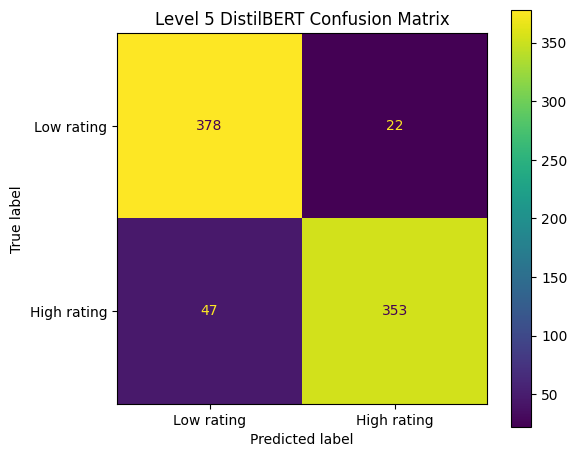

Confusion matrix saved to: /content/outputs/figures/level5_confusion_matrix.png
Confusion matrix values:
[[378  22]
 [ 47 353]]


In [46]:
# Create and save confusion matrix

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low rating", "High rating"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format="d")

plt.title("Level 5 DistilBERT Confusion Matrix")
plt.tight_layout()

figure_path = f"{FIGURE_DIR}/level5_confusion_matrix.png"
plt.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", figure_path)

print("Confusion matrix values:")
print(cm)

In [47]:
# Generate classification report

report = classification_report(
    y_true,
    y_pred,
    target_names=["Low rating", "High rating"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    f"{TABLE_DIR}/level5_classification_report.csv",
    index=True
)

report_df

,precision,recall,f1-score,support
Low rating,0.889412,0.94500,0.916364,400.00000
High rating,0.941333,0.88250,0.910968,400.00000
accuracy,0.913750,0.91375,0.913750,0.91375
macro avg,0.915373,0.91375,0.913666,800.00000
weighted avg,0.915373,0.91375,0.913666,800.00000


## 22. Error Analysis

This section examines misclassified reviews to understand where the DistilBERT classifier struggles. The goal is not only to report model performance, but also to interpret model errors from a UX research perspective.

In [48]:
# Add predictions back to the test dataframe for error analysis

test_results_df = test_df.copy()
test_results_df["true_label"] = y_true
test_results_df["predicted_label"] = y_pred

test_results_df["true_label_name"] = test_results_df["true_label"].map({
    0: "Low rating",
    1: "High rating"
})

test_results_df["predicted_label_name"] = test_results_df["predicted_label"].map({
    0: "Low rating",
    1: "High rating"
})

# Error type
test_results_df["error_type"] = "Correct"

test_results_df.loc[
    (test_results_df["true_label"] == 0) & (test_results_df["predicted_label"] == 1),
    "error_type"
] = "Low rating predicted as High rating"

test_results_df.loc[
    (test_results_df["true_label"] == 1) & (test_results_df["predicted_label"] == 0),
    "error_type"
] = "High rating predicted as Low rating"

print("Prediction result counts:")
print(test_results_df["error_type"].value_counts())

print("\nExamples: Low rating predicted as High rating")
display(
    test_results_df[
        test_results_df["error_type"] == "Low rating predicted as High rating"
    ][[
        "app_name",
        "rating",
        "rating_group",
        "predicted_label_name",
        "clean_text"
    ]].head(10)
)

print("\nExamples: High rating predicted as Low rating")
display(
    test_results_df[
        test_results_df["error_type"] == "High rating predicted as Low rating"
    ][[
        "app_name",
        "rating",
        "rating_group",
        "predicted_label_name",
        "clean_text"
    ]].head(10)
)

Prediction result counts:
error_type
Correct                                731
High rating predicted as Low rating     47
Low rating predicted as High rating     22
Name: count, dtype: int64

Examples: Low rating predicted as High rating


,app_name,rating,rating_group,predicted_label_name,clean_text
23,blockapp,1,Low rating,High rating,working properly
82,reflectly,2,Low rating,High rating,im disappointed new update though like freedom...
86,fabulous,2,Low rating,High rating,app used really good become bloated extremely ...
194,voice,1,Low rating,High rating,app helpful
208,constant,1,Low rating,High rating,expected use recommend
225,digitalwellbeing,1,Low rating,High rating,easy circumvent whats point pause app opening
230,reflexio,1,Low rating,High rating,really help show improvment
326,headspace,2,Low rating,High rating,love actually help sleep downfall keep crashin...
348,minddoc,2,Low rating,High rating,help free look right place free gonna keep loo...
353,talkspace,2,Low rating,High rating,good therapy terrible appaccessibility



Examples: High rating predicted as Low rating


,app_name,rating,rating_group,predicted_label_name,clean_text
0,blockapp,4,High rating,Low rating,please remove pop window blocking notif instea...
15,talkspace,5,High rating,Low rating,three job price issue money would definitely r...
45,daylio,4,High rating,Low rating,app purchase
52,cbtguide,5,High rating,Low rating,serious site breath fresh air secret force
62,minddoc,5,High rating,Low rating,struggling liking body bothering friend tried ...
113,fabulous,5,High rating,Low rating,im shocker sticking daily regimen task still e...
115,calm,4,High rating,Low rating,really like app especially soundscapes use hel...
120,talkspace,5,High rating,Low rating,covered insurance need therapy worth every pen...
172,calm,5,High rating,Low rating,aoid phone way many advertizments subject ever...
205,calm,5,High rating,Low rating,yearly plan inexpensive use daily benefit get ...


In [49]:
# Save error analysis summary without exporting full review text

error_analysis_summary = (
    test_results_df["error_type"]
    .value_counts()
    .reset_index()
)

error_analysis_summary.columns = ["error_type", "count"]
error_analysis_summary["percentage_of_test_set"] = (
    error_analysis_summary["count"] / len(test_results_df) * 100
).round(2)

error_analysis_summary["ux_interpretation"] = error_analysis_summary["error_type"].map({
    "Correct": "The model prediction matches the rating-derived satisfaction label.",
    "Low rating predicted as High rating": "These reviews may contain positive language despite low ratings, often reflecting mixed experiences or complaints about specific issues such as pricing, access, or bugs.",
    "High rating predicted as Low rating": "These reviews may contain negative words or specific frustrations despite high ratings, or may reflect mixed sentiment and short ambiguous review text."
})

error_analysis_summary.to_csv(
    f"{TABLE_DIR}/level5_error_analysis_summary.csv",
    index=False
)

error_analysis_summary

,error_type,count,percentage_of_test_set,ux_interpretation
0,Correct,731,91.38,The model prediction matches the rating-derive...
1,High rating predicted as Low rating,47,5.88,These reviews may contain negative words or sp...
2,Low rating predicted as High rating,22,2.75,These reviews may contain positive language de...


## 23. Level 5 Summary

Level 5 fine-tuned a DistilBERT model to classify low-rating versus high-rating reviews using review text.

The task was framed as a rating-derived user satisfaction classification problem rather than a clinical prediction task. The model does not predict mental health conditions, suicide risk, diagnosis, or individual psychological status.

The model achieved strong performance on the balanced test set, with accuracy and F1-score above 0.91. This suggests that review text contains clear linguistic signals associated with low and high user satisfaction.

The confusion matrix and error analysis show that most reviews were correctly classified. Misclassified cases often involved short, ambiguous, or mixed reviews. Some low-rating reviews contained positive language, while some high-rating reviews included complaints about pricing, access, advertisements, or specific usability issues.

These findings support the broader project argument: machine learning models can help analyse large-scale UX feedback in digital mental health apps, but model outputs should be interpreted alongside qualitative UX reasoning, rule-based analysis, and topic modelling rather than treated as automatic ground truth.

## 24. Output Files Check

This section checks the figures and tables generated by the Level 4–5 notebook.

In [52]:
# Check saved output files

print("Figures:")
for file in sorted(os.listdir(FIGURE_DIR)):
    print("-", file)

print("\nTables:")
for file in sorted(os.listdir(TABLE_DIR)):
    print("-", file)

Figures:
- level4_sentiment_by_rating_group.png
- level4_zero_shot_pain_point_distribution.png
- level5_confusion_matrix.png

Tables:
- level4_5_cleaned_data_summary.csv
- level4_5_raw_data_summary.csv
- level4_disagreement_summary.csv
- level4_method_comparison.csv
- level4_sentiment_summary.csv
- level4_zero_shot_pain_point_summary.csv
- level4_zero_shot_results_anonymised.csv
- level5_classification_report.csv
- level5_error_analysis_summary.csv
- level5_model_metrics.csv


## 25. Overall Limitations

Several limitations should be considered when interpreting the Level 4–5 results.

First, the transformer-assisted analyses were conducted on stratified samples rather than the full dataset. This was necessary to keep the notebook computationally feasible in Colab.

Second, the sentiment and zero-shot models are general-purpose pre-trained models. They were not specifically trained on mental health app reviews, so their outputs may be less reliable for short, informal, sarcastic, or heavily cleaned review text.

Third, zero-shot classification depends strongly on the candidate labels provided by the researcher. The high proportion of unclear classifications suggests that some reviews do not map neatly onto the predefined UX pain point categories.

Fourth, the Level 5 DistilBERT model predicts rating-derived user satisfaction, not clinical status. The labels come from app store ratings, which are subjective and may reflect multiple factors such as pricing, technical problems, content quality, trust, or customer support.

Finally, this project should be interpreted as an applied UX and digital health data analysis project. The goal is to generate interpretable product and service design insights from user reviews, not to provide clinical assessment or diagnostic inference.